# 05 — Active spin vs gyro spin

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jman4162/pitchphys/blob/main/notebooks/05_active_spin_vs_gyro_spin.ipynb)

Spin rate alone does not determine pitch movement. The *direction* of the spin axis matters: only the component of `ω` perpendicular to velocity contributes to the Magnus force. The parallel component (gyro spin) doesn't move the ball.

This notebook holds total spin constant at 2,500 rpm and sweeps the active-spin fraction from 0 to 1, showing how break collapses as the pitch becomes more 'gyro-like'.

Reference: SPEC §4.4 — 'Spin rate is not movement.'

In [1]:
# Auto-install pitchphys when running on Colab.
import sys

if "google.colab" in sys.modules:
    !pip install -q "pitchphys[viz] @ git+https://github.com/jman4162/pitchphys.git"

import pitchphys

print(f"pitchphys {pitchphys.__version__}")

pitchphys 0.2.0


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pitchphys import simulate
from pitchphys.core.pitch import PitchRelease
from pitchphys.viz.plot3d import compare_pitches_3d

## 1. Sweep active fraction

21 samples from 0 (pure gyro) to 1 (pure active spin). Total spin and tilt are held constant.

In [3]:
fractions = np.linspace(0.0, 1.0, 21)
rows = []
trajs = []
for a in fractions:
    pitch = PitchRelease.from_mph_rpm_axis(
        speed_mph=92.0,
        spin_rpm=2500.0,
        tilt_clock=12.0,
        active_spin_fraction=float(a),
    )
    traj = simulate(pitch)
    trajs.append(traj)
    rows.append(
        {
            "active_fraction": a,
            "IVB_in": traj.induced_vertical_break_in,
            "horizontal_break_in": traj.horizontal_break_in,
            "magnus_break_magnitude_in": traj.magnus_break_magnitude_in,
        }
    )
df = pd.DataFrame(rows)
df.head()

,active_fraction,IVB_in,horizontal_break_in,magnus_break_magnitude_in
0,0.00,1.845253,-1.431484,1.432196
1,0.05,3.998027,-1.335452,2.588742
2,0.10,6.144981,-1.236514,4.558190
3,0.15,8.289270,-1.135537,6.651615
4,0.20,10.431729,-1.033200,8.778966


## 2. Plot the sweep

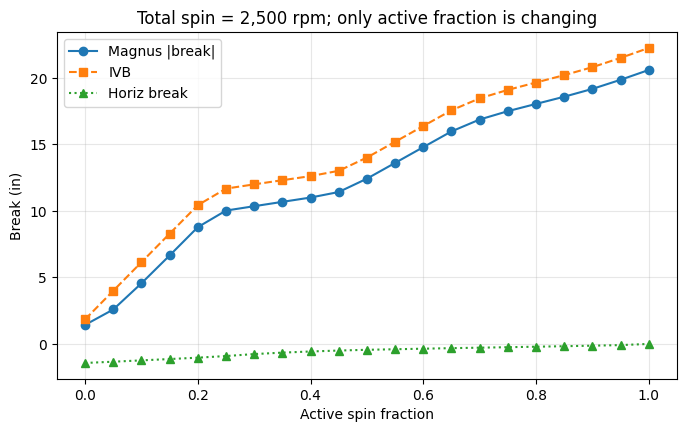

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(df["active_fraction"], df["magnus_break_magnitude_in"], "o-", label="Magnus |break|")
ax.plot(df["active_fraction"], df["IVB_in"], "s--", label="IVB")
ax.plot(df["active_fraction"], df["horizontal_break_in"], "^:", label="Horiz break")
ax.set_xlabel("Active spin fraction")
ax.set_ylabel("Break (in)")
ax.set_title("Total spin = 2,500 rpm; only active fraction is changing")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

At fraction 0, the spin axis is fully aligned with velocity — there's no perpendicular component, so Magnus break is essentially zero. As the active fraction rises toward 1, the full Magnus break is realized.

**The takeaway**: a 2,500 rpm gyro slider has the same total spin as a 2,500 rpm 4-seam fastball — and yet the slider has roughly *no* vertical break.

## 3. Trajectories at three key fractions

In [5]:
key_indices = [0, 10, len(fractions) - 1]
subset = [trajs[i] for i in key_indices]
labels = [f"active={fractions[i]:.2f}" for i in key_indices]
fig3d = compare_pitches_3d(subset, labels=labels)
fig3d.show()

## Takeaway

Pitch movement depends on spin **rate** AND spin **direction**. Two pitches with identical rpm can produce drastically different break, depending on how much of that spin is genuinely perpendicular to the ball's velocity. This is why Statcast publishes 'Active Spin %' as a first-class metric alongside spin rate.